In [1]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import cross_val_score

from sklearn import metrics
from collections import Counter

In [2]:
# сразу напишем код функции, которая будет вычислять все нужные метрики

def Reg_Models_Evaluation_Metrics (model,X_train,y_train,X_test,y_test,y_pred):
    cv_score = cross_val_score(estimator = model, X = X_train, y = y_train, cv = 10)

    # Calculating Adjusted R-squared
    r2 = model.score(X_test, y_test)
    # Number of observations is the shape along axis 0
    n = X_test.shape[0]
    # Number of features (predictors, p) is the shape along axis 1
    p = X_test.shape[1]
    # Adjusted R-squared formula
    adjusted_r2 = 1-(1-r2)*(n-1)/(n-p-1)
    RMSE = np.sqrt(metrics.mean_squared_error(y_test, y_pred))
    R2 = model.score(X_test, y_test)
    CV_R2 = cv_score.mean()

    print(f'RMSE:  {round(RMSE,4)}\n  R2: {round(R2,4)}\n Adjusted R2: {round(adjusted_r2, 4)}\n Cross Validated R2: {round(cv_score.mean(),4)}')
    return R2, adjusted_r2, CV_R2, RMSE

# Линейная регрессия

In [21]:
# импорт нужных библиотек
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing  # подключаем датасет из sklearn
import warnings
warnings.filterwarnings('ignore')

In [26]:
# 1. Генерация случайного датасета для регрессии
print("1. ГЕНЕРАЦИЯ ДАТАСЕТА")
np.random.seed(42)
X, y = make_regression(n_samples=1000, n_features=4, n_informative=3,
                       noise=15, random_state=42)

# Создаем DataFrame для удобства анализа
feature_names = ['feature_1', 'feature_2', 'feature_3', 'feature_4']
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

print(f"Размер датасета: {df.shape}")
print("\nПервые 5 строк:")
df.head()

1. ГЕНЕРАЦИЯ ДАТАСЕТА
Размер датасета: (1000, 5)

Первые 5 строк:


,feature_1,feature_2,feature_3,feature_4,target
0,-0.898415,-0.576904,0.950424,0.491919,-34.643268
1,-0.361463,-1.014759,2.086047,0.416446,44.839018
2,1.006293,-0.384556,-0.860413,-0.576892,53.841162
3,-2.929449,-0.560608,-0.127655,2.052972,-277.000619
4,-1.191303,0.473833,1.865775,0.656554,11.753866


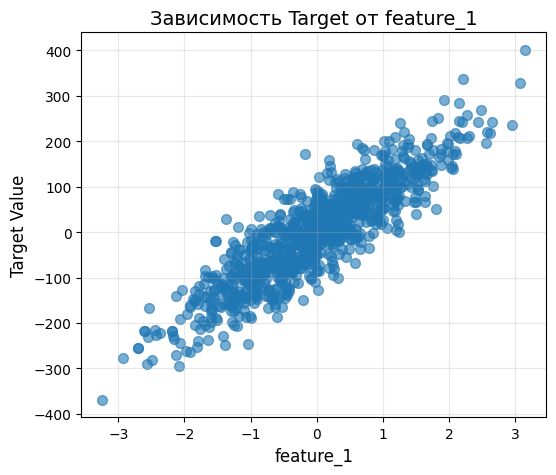

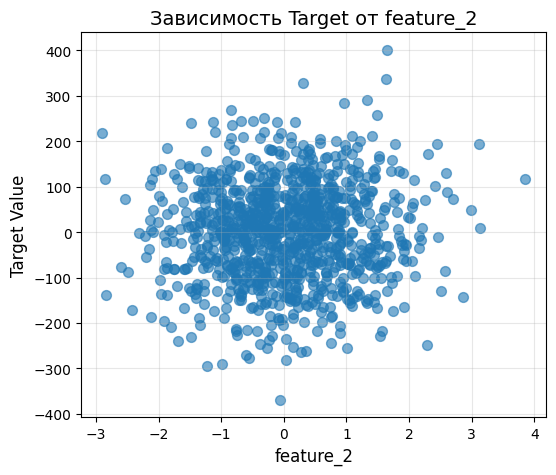

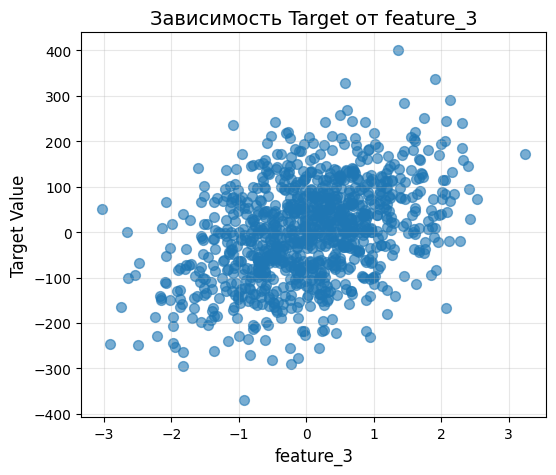

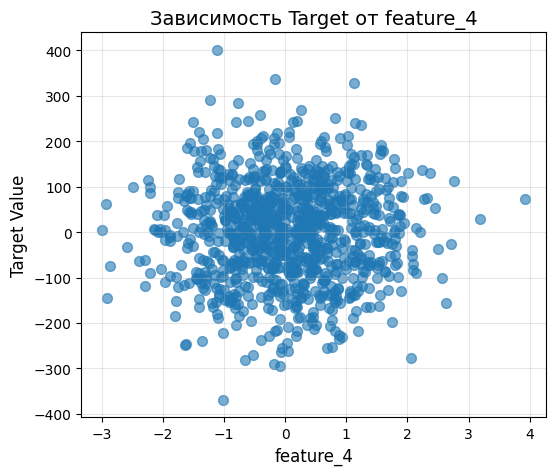

In [27]:
for feature_name in feature_names:
    plt.figure(figsize=(6, 5))
    plt.scatter(df[feature_name], df['target'], alpha=0.6, s=50)
    plt.ylabel('Target Value', size=12)
    plt.xlabel(feature_name, size=12)
    plt.title(f'Зависимость Target от {feature_name}', size=14)
    plt.grid(True, alpha=0.3)

In [29]:
# подготавливаем датасет к обучению

X = df.drop(['target'], axis=1)
y = df['target']
print(f'X shape: {X.shape} | y shape: {y.shape} ')

X shape: (1000, 4) | y shape: (1000,) 


In [30]:
# делим датасет на трейн и тест

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=15)

In [31]:
from sklearn.linear_model import LinearRegression

# Create a linear regression model
modelLR = LinearRegression()

# Fit the model to the data
modelLR.fit(X_train, y_train)

# Predict the response for a new data point
y_pr_LR = modelLR.predict(X_test)

In [32]:
_ = Reg_Models_Evaluation_Metrics(modelLR, X_train, y_train, X_test, y_test, y_pr_LR)


RMSE:  14.9214
  R2: 0.9832
 Adjusted R2: 0.9829
 Cross Validated R2: 0.9796


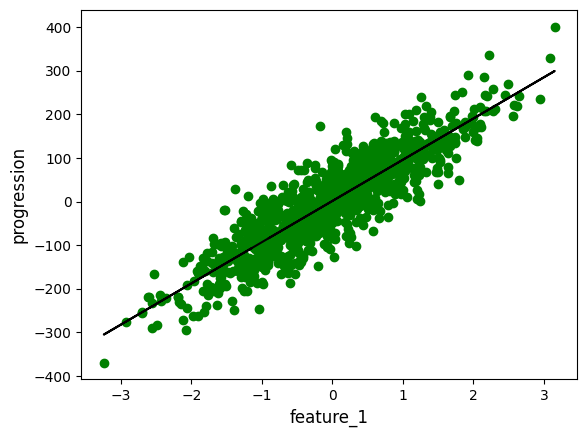

In [37]:
# попробуем отрисовать, как выглядит наша линейная регрессия

X2 = df['feature_1'].values[:,np.newaxis]
# target data is array of shape (n,)
y2 = df['target'].values


model2 = LinearRegression()
model2.fit(X2, y2)

plt.scatter(X2, y2,color='g')
plt.plot(X2, model2.predict(X2),color='k')
plt.ylabel('progression', size=12)
plt.xlabel('feature_1', size=12)
plt.show()



# Полиномиальная регрессия

In [38]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=3, include_bias=False)

poly_features = poly.fit_transform(X)
X_p_train, X_p_test, y_p_train, y_p_test = train_test_split(poly_features, y, test_size=0.3, random_state=42)

In [39]:
# Create a linear regression model
modelPR = LinearRegression()

# Fit the model to the data
modelPR.fit(X_p_train, y_p_train)

# Predict the response for a new data point
y_pr_PR = modelPR.predict(X_p_test)

_ = Reg_Models_Evaluation_Metrics(modelPR, X_p_train, y_p_train, X_p_test, y_p_test, y_pr_PR)

RMSE:  14.3315
  R2: 0.9821
 Adjusted R2: 0.9798
 Cross Validated R2: 0.9785


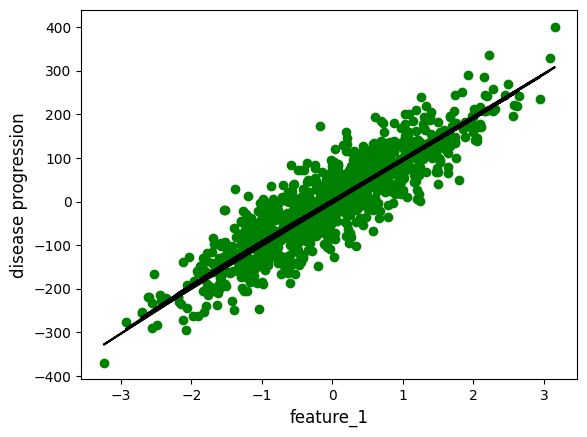

In [40]:
X2 = df['feature_1'].values[:,np.newaxis]
# target data is array of shape (n,)
y2 = df['target'].values

poly_features = poly.fit_transform(X2)

model2 = LinearRegression()
model2.fit(poly_features, y2)


plt.scatter(X2, y2,color='g')
plt.plot(X2, model2.predict(poly.fit_transform(X2)),color='k')
plt.ylabel('disease progression', size=12)
plt.xlabel('feature_1', size=12)
plt.show()


# Регрессия дерева принятия решений

In [41]:
from sklearn.tree import DecisionTreeRegressor

# Create a stepwise regression model
modelDT = DecisionTreeRegressor()

# Fit the model to the data
modelDT.fit(X_train, y_train)

# Predict the response for a new data point
y_dt_pred = modelDT.predict(X_test)

In [42]:
_ = Reg_Models_Evaluation_Metrics(modelDT, X_train, y_train, X_test, y_test, y_dt_pred)

RMSE:  30.2193
  R2: 0.9313
 Adjusted R2: 0.9298
 Cross Validated R2: 0.9294


# Регрессия случайного леса

In [43]:
from sklearn.ensemble import RandomForestRegressor

# Create a stepwise regression model
modelRF = RandomForestRegressor(n_estimators=100)

# Fit the model to the data
modelRF.fit(X_train, y_train)

# Predict the response for a new data point
y_rf_pred = modelRF.predict(X_test)


_ = Reg_Models_Evaluation_Metrics(modelRF, X_train, y_train, X_test, y_test, y_rf_pred)

RMSE:  21.7446
  R2: 0.9644
 Adjusted R2: 0.9637
 Cross Validated R2: 0.9643


# Регрессия опорных векторов (SVR)

In [44]:
from sklearn.svm import SVR

# Create a support vector regression model
modelSVR = SVR(kernel='linear')

modelSVR.fit(X_train, y_train)

# Predict the response for a new data point
y_rf_pred = modelSVR.predict(X_test)


_ = Reg_Models_Evaluation_Metrics(modelSVR, X_train, y_train, X_test, y_test, y_rf_pred)

RMSE:  15.0695
  R2: 0.9829
 Adjusted R2: 0.9826
 Cross Validated R2: 0.9789


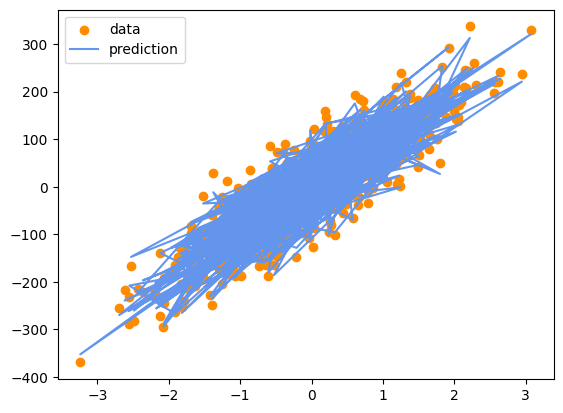

In [45]:
plt.scatter(X_train["feature_1"], y_train, color='darkorange',
            label='data')
plt.plot(X_train["feature_1"], modelSVR.predict(X_train), color='cornflowerblue',
         label='prediction')
plt.legend()
plt.show()

In [46]:
from sklearn.svm import SVR

# Create a support vector regression model. Полиномиальное ядро
modelSVR = SVR(kernel='poly')

modelSVR.fit(X_train, y_train)

# Predict the response for a new data point
y_rf_pred = modelSVR.predict(X_test)


_ = Reg_Models_Evaluation_Metrics(modelSVR, X_train, y_train, X_test, y_test, y_rf_pred)

RMSE:  58.6471
  R2: 0.7411
 Adjusted R2: 0.7358
 Cross Validated R2: 0.7206


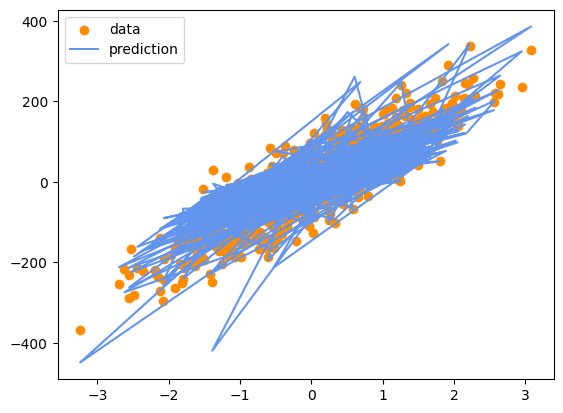

In [47]:
plt.scatter(X_train["feature_1"], y_train, color='darkorange',
            label='data')
plt.plot(X_train["feature_1"], modelSVR.predict(X_train), color='cornflowerblue',
         label='prediction')
plt.legend()
plt.show()

In [48]:

# Create a support vector regression model. Ядро - радиальная базисная функция
modelSVR = SVR(kernel='rbf')

modelSVR.fit(X_train, y_train)

# Predict the response for a new data point
y_rf_pred = modelSVR.predict(X_test)


_ = Reg_Models_Evaluation_Metrics(modelSVR, X_train, y_train, X_test, y_test, y_rf_pred)

RMSE:  79.8808
  R2: 0.5197
 Adjusted R2: 0.5098
 Cross Validated R2: 0.5451


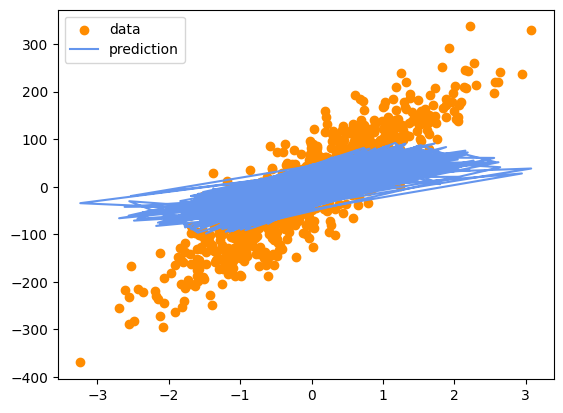

In [49]:
plt.scatter(X_train["feature_1"], y_train, color='darkorange',
            label='data')
plt.plot(X_train["feature_1"], modelSVR.predict(X_train), color='cornflowerblue',
         label='prediction')
plt.legend()
plt.show()

# Регрессия ElasticNet

In [50]:
from sklearn.linear_model import ElasticNet

# Create an elastic net regression model
modelEN = ElasticNet(alpha=0.1, l1_ratio=0.8)

# Fit the model to the data
modelEN.fit(X_train, y_train)

# Predict the response for a new data point
y_en_pred = modelEN.predict(X_test)

_ = Reg_Models_Evaluation_Metrics(modelEN, X_train, y_train, X_test, y_test, y_en_pred)

RMSE:  15.1644
  R2: 0.9827
 Adjusted R2: 0.9823
 Cross Validated R2: 0.9791


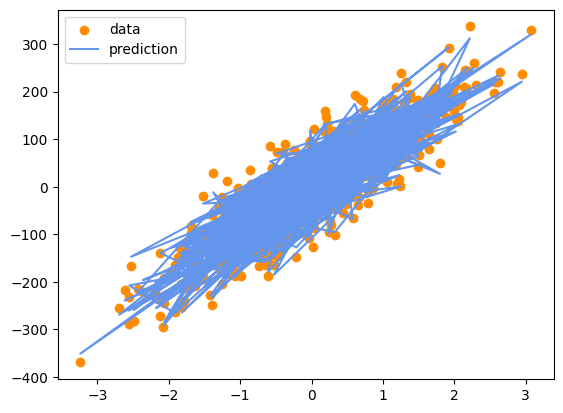

In [51]:
plt.scatter(X_train["feature_1"], y_train, color='darkorange',
            label='data')
plt.plot(X_train["feature_1"], modelEN.predict(X_train), color='cornflowerblue',
         label='prediction')
plt.legend()
plt.show()